X_train shape: (6510, 43)
X_test shape: (240, 43)

Reduced smooth columns:
['rolling_mean_4', 'lag_4', 'rolling_mean_8', 'avg_price', 'price_rolling_4', 'time_index', 'cat_share_lag1']

Reduced linear columns:
['wm_yr_wk', 'n_days', 'month', 'lag_1', 'lag_2', 'lag_52', 'rolling_std_4', 'momentum', 'recent_cv', 'week_of_year', 'month_sin', 'month_cos', 'woy_sin', 'woy_cos', 'near_payday', 'national_events', 'other_events', 'snap_days', 'price_relative', 'store_traffic_lag1', 'cat_id_FOODS', 'cat_id_HOBBIES', 'cat_id_HOUSEHOLD', 'store_id_CA_1', 'store_id_CA_2', 'store_id_CA_3', 'store_id_CA_4', 'store_id_TX_1', 'store_id_TX_2', 'store_id_TX_3', 'store_id_WI_1', 'store_id_WI_2', 'store_id_WI_3', 'state_id_CA', 'state_id_TX', 'state_id_WI']

Reduced-feature GAM tuning results (sorted by test sMAPE):


,lam,train_RMSE,train_MAE,train_MAPE,train_sMAPE,test_RMSE,test_MAE,test_MAPE,test_sMAPE
0,5.00,727.074,467.634,6.998,6.920,817.923,462.082,4.840,4.862
1,10.00,729.640,468.576,6.998,6.919,807.567,461.956,5.008,4.978
2,25.00,733.340,469.765,6.984,6.906,798.895,466.706,5.329,5.246
3,50.00,736.550,470.943,6.975,6.899,793.714,468.844,5.520,5.406
4,100.00,740.314,472.793,6.977,6.904,789.522,468.942,5.622,5.488
5,1.00,721.958,465.000,6.980,6.907,887.324,520.481,5.810,6.072
6,0.60,720.648,464.280,6.978,6.907,937.266,579.437,7.025,7.470
7,0.10,717.354,462.928,6.991,6.924,1270.458,966.982,14.887,17.337
8,0.01,715.007,462.515,7.011,6.946,1626.937,1330.248,22.163,28.493



Best lam for reduced-feature GAM based on test sMAPE: 5

Best reduced-feature GAM - Train metrics
RMSE: 727.074
MAE: 467.634
MAPE: 6.998
sMAPE: 6.920
NRMSE_%_of_mean_sales: 8.640
MAE_%_of_mean_sales: 5.557

Best reduced-feature GAM - Test metrics
RMSE: 817.923
MAE: 462.082
MAPE: 4.840
sMAPE: 4.862
NRMSE_%_of_mean_sales: 8.146
MAE_%_of_mean_sales: 4.602

Comparison across GAM variants


,model,MAE,RMSE,MAPE,sMAPE
0,"GAM (Tuned Raw Demand, lam=10)",463.540,824.147,4.676,4.669
1,"GAM (Tuned Log Demand, lam=100)",487.293,893.074,4.668,4.762
2,"GAM (Reduced Feature, lam=5)",462.082,817.923,4.840,4.862


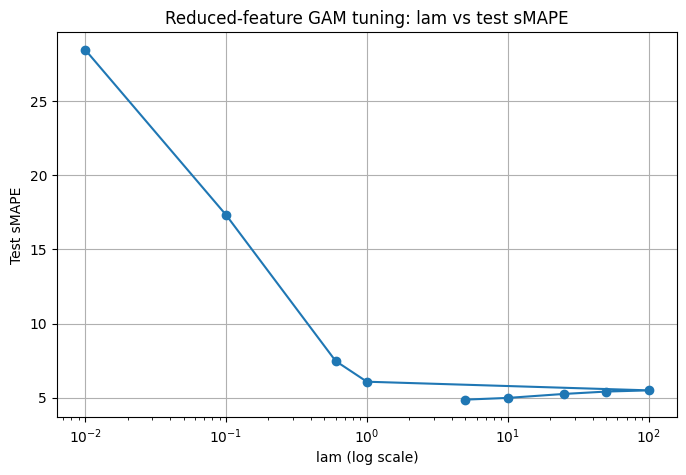


Top 5 reduced-feature smooth terms


,term_index,feature,partial_dependence_range
0,7,rolling_mean_4,21479.553
1,5,lag_4,10895.437
2,9,rolling_mean_8,9285.896
3,23,price_rolling_4,9077.486
4,22,avg_price,8792.600


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pygam import LinearGAM, s, l
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================================================
# 1. Load data
# =========================================================
train = pd.read_csv("training.csv", parse_dates=["week_start"])
test = pd.read_csv("test.csv", parse_dates=["week_start"])

target = "weekly_units"
drop_cols = ["weekly_units", "week_start"]
feature_cols = [c for c in train.columns if c not in drop_cols]

X_train = train[feature_cols].copy()
y_train = train[target].copy()

X_test = test[feature_cols].copy()
y_test = test[target].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# =========================================================
# 2. Reduced smooth feature set
# =========================================================
smooth_cols_reduced = [
    "rolling_mean_4",
    "lag_4",
    "rolling_mean_8",
    "avg_price",
    "price_rolling_4",
    "time_index",
    "cat_share_lag1",
]

linear_cols_reduced = [c for c in feature_cols if c not in smooth_cols_reduced]
col_index = {col: i for i, col in enumerate(feature_cols)}

print("\nReduced smooth columns:")
print(smooth_cols_reduced)

print("\nReduced linear columns:")
print(linear_cols_reduced)

# =========================================================
# 3. Build reduced GAM terms
# =========================================================
terms_reduced = None
for col in feature_cols:
    idx = col_index[col]
    term = s(idx) if col in smooth_cols_reduced else l(idx)
    terms_reduced = term if terms_reduced is None else terms_reduced + term

# =========================================================
# 4. Metrics
# =========================================================
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    mask = denom != 0
    if mask.sum() == 0:
        return np.nan
    return 100 * np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask])

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mean_sales = np.mean(y_true)
    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "NRMSE_%_of_mean_sales": (100 * rmse / mean_sales) if mean_sales != 0 else np.nan,
        "MAE_%_of_mean_sales": (100 * mae / mean_sales) if mean_sales != 0 else np.nan,
    }

# =========================================================
# 5. Tune lam for reduced-feature GAM
# =========================================================
lam_grid = [0.01, 0.1, 0.6, 1, 5, 10, 25, 50, 100]

tuning_results_reduced = []
best_gam_reduced = None
best_lam_reduced = None
best_score_reduced = np.inf  # primary criterion = lowest test sMAPE

for lam in lam_grid:
    gam_reduced = LinearGAM(terms_reduced, lam=lam)
    gam_reduced.fit(X_train.values, y_train.values)

    train_pred = gam_reduced.predict(X_train.values)
    test_pred = gam_reduced.predict(X_test.values)

    train_pred = np.clip(train_pred, a_min=0, a_max=None)
    test_pred = np.clip(test_pred, a_min=0, a_max=None)

    train_metrics = evaluate(y_train, train_pred)
    test_metrics = evaluate(y_test, test_pred)

    row = {
        "lam": lam,
        "train_RMSE": train_metrics["RMSE"],
        "train_MAE": train_metrics["MAE"],
        "train_MAPE": train_metrics["MAPE"],
        "train_sMAPE": train_metrics["sMAPE"],
        "test_RMSE": test_metrics["RMSE"],
        "test_MAE": test_metrics["MAE"],
        "test_MAPE": test_metrics["MAPE"],
        "test_sMAPE": test_metrics["sMAPE"],
    }
    tuning_results_reduced.append(row)

    if test_metrics["sMAPE"] < best_score_reduced:
        best_score_reduced = test_metrics["sMAPE"]
        best_gam_reduced = gam_reduced
        best_lam_reduced = lam

# =========================================================
# 6. Tuning results
# =========================================================
tuning_df_reduced = pd.DataFrame(tuning_results_reduced).sort_values("test_sMAPE").reset_index(drop=True)

print("\nReduced-feature GAM tuning results (sorted by test sMAPE):")
display(tuning_df_reduced.round(3))

print(f"\nBest lam for reduced-feature GAM based on test sMAPE: {best_lam_reduced}")

# =========================================================
# 7. Final reduced GAM predictions
# =========================================================
best_train_pred_reduced = best_gam_reduced.predict(X_train.values)
best_test_pred_reduced = best_gam_reduced.predict(X_test.values)

best_train_pred_reduced = np.clip(best_train_pred_reduced, a_min=0, a_max=None)
best_test_pred_reduced = np.clip(best_test_pred_reduced, a_min=0, a_max=None)

best_train_metrics_reduced = evaluate(y_train, best_train_pred_reduced)
best_test_metrics_reduced = evaluate(y_test, best_test_pred_reduced)

print("\nBest reduced-feature GAM - Train metrics")
for k, v in best_train_metrics_reduced.items():
    print(f"{k}: {v:.3f}")

print("\nBest reduced-feature GAM - Test metrics")
for k, v in best_test_metrics_reduced.items():
    print(f"{k}: {v:.3f}")

# =========================================================
# 8. Compare all GAM variants
# =========================================================
comparison_df = pd.DataFrame([
    {
        "model": "GAM (Tuned Raw Demand, lam=10)",
        "MAE": 463.540,
        "RMSE": 824.147,
        "MAPE": 4.676,
        "sMAPE": 4.669,
    },
    {
        "model": "GAM (Tuned Log Demand, lam=100)",
        "MAE": 487.293,
        "RMSE": 893.074,
        "MAPE": 4.668,
        "sMAPE": 4.762,
    },
    {
        "model": f"GAM (Reduced Feature, lam={best_lam_reduced})",
        "MAE": best_test_metrics_reduced["MAE"],
        "RMSE": best_test_metrics_reduced["RMSE"],
        "MAPE": best_test_metrics_reduced["MAPE"],
        "sMAPE": best_test_metrics_reduced["sMAPE"],
    }
])

print("\nComparison across GAM variants")
display(comparison_df.round(3))

# =========================================================
# 9. Plot lam vs test sMAPE
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(tuning_df_reduced["lam"], tuning_df_reduced["test_sMAPE"], marker="o")
plt.xscale("log")
plt.xlabel("lam (log scale)")
plt.ylabel("Test sMAPE")
plt.title("Reduced-feature GAM tuning: lam vs test sMAPE")
plt.grid(True)
plt.show()

# =========================================================
# 10. Top-5 interpretability for reduced-feature GAM
# =========================================================
smooth_term_info_reduced = []

for i, term in enumerate(best_gam_reduced.terms):
    if term.isintercept:
        continue

    feature_idx = getattr(term, "feature", None)
    if feature_idx is None:
        continue

    feature_name = feature_cols[feature_idx]
    if feature_name not in smooth_cols_reduced:
        continue

    XX = best_gam_reduced.generate_X_grid(term=i)
    pdep = best_gam_reduced.partial_dependence(term=i, X=XX)

    effect_range = float(np.max(pdep) - np.min(pdep))

    smooth_term_info_reduced.append({
        "term_index": i,
        "feature": feature_name,
        "partial_dependence_range": effect_range
    })

top5_terms_reduced = (
    pd.DataFrame(smooth_term_info_reduced)
    .sort_values("partial_dependence_range", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

print("\nTop 5 reduced-feature smooth terms")
display(top5_terms_reduced.round(3))